In [1]:
import pandas as pd

path = "/Users/jakobwerkgarner/Desktop/calibration_summary_all_runs.csv"

In [3]:
dat = pd.read_csv(path)

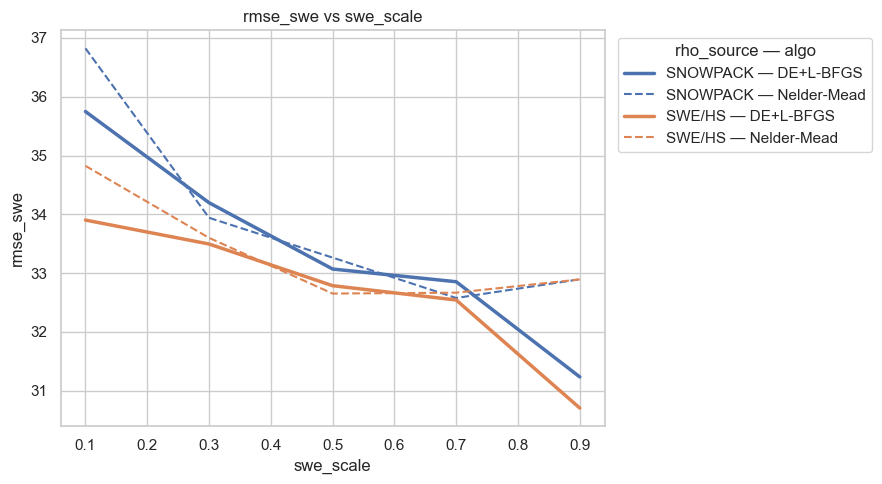

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

plt.figure(figsize=(7, 4))

for algo in dat["algorithm"].unique():
    
    d = dat[dat["algorithm"] == algo].sort_values("swe_scale")
    
    linestyle = "-" if "DE" in algo else "--"
    
    for rho in d["rho_source"].unique():
        dd = d[d["rho_source"] == rho]
        
        plt.plot(
            dd["swe_scale"],
            dd["rmse_swe"],
            marker="o",
            linestyle=linestyle,
            label=f"{algo} | {rho}"
        )

plt.xlabel("swe_scale")
plt.ylabel("rmse_swe")
plt.title("rmse_swe vs swe_scale (all algorithms)")

plt.legend()
plt.tight_layout()
plt.show()

In [9]:
dat

,summary_block,rho_source,algorithm,run,swe_scale,rho_scale,score,rmse_swe,rmse_rho,rho_max,rho_null,c_ov,k_ov,k,tau,eta_null
0,"DE + L-BFGS, rho = SWE/HS",SWE/HS,DE+L-BFGS,1,0.9,0.1,33.252835,30.707006,56.165294,470.303986,54.057794,0.000778,4.309159,0.029601,0.101705,1186727.0
1,"DE + L-BFGS, rho = SWE/HS",SWE/HS,DE+L-BFGS,2,0.7,0.3,38.200613,32.543786,51.399876,446.007212,86.055351,0.000900,2.360653,0.021458,0.020786,12228150.0
2,"DE + L-BFGS, rho = SWE/HS",SWE/HS,DE+L-BFGS,3,0.5,0.5,41.705506,32.787084,50.623928,435.200797,87.532238,0.000869,4.326521,0.020795,0.022339,12519290.0
3,"DE + L-BFGS, rho = SWE/HS",SWE/HS,DE+L-BFGS,4,0.3,0.7,45.378243,33.495499,50.470847,429.117973,87.801553,0.000548,4.586821,0.019864,0.023378,13657410.0
4,"DE + L-BFGS, rho = SWE/HS",SWE/HS,DE+L-BFGS,5,0.1,0.9,48.506487,33.902349,50.129169,423.091039,88.257531,0.000228,3.480819,0.023448,0.023054,7542367.0
5,"DE + L-BFGS, rho = SNOWPACK",SNOWPACK,DE+L-BFGS,1,0.9,0.1,34.926704,31.235910,68.143857,473.430400,51.310607,0.000913,6.750846,0.028076,0.103385,1289350.0
6,"DE + L-BFGS, rho = SNOWPACK",SNOWPACK,DE+L-BFGS,2,0.7,0.3,41.325832,32.854094,61.093219,443.935493,86.067052,0.000603,1.936398,0.023535,0.022456,7697576.0
7,"DE + L-BFGS, rho = SNOWPACK",SNOWPACK,DE+L-BFGS,3,0.5,0.5,46.837428,33.070196,60.604660,442.480488,94.311588,0.000234,5.027839,0.023642,0.021052,8545607.0
8,"DE + L-BFGS, rho = SNOWPACK",SNOWPACK,DE+L-BFGS,4,0.3,0.7,52.191516,34.197402,59.903280,435.370064,96.828448,0.000599,2.508865,0.024919,0.021382,6532730.0
9,"DE + L-BFGS, rho = SNOWPACK",SNOWPACK,DE+L-BFGS,5,0.1,0.9,57.283848,35.747474,59.676779,421.432934,107.145930,0.000395,5.221181,0.023553,0.020861,9535911.0


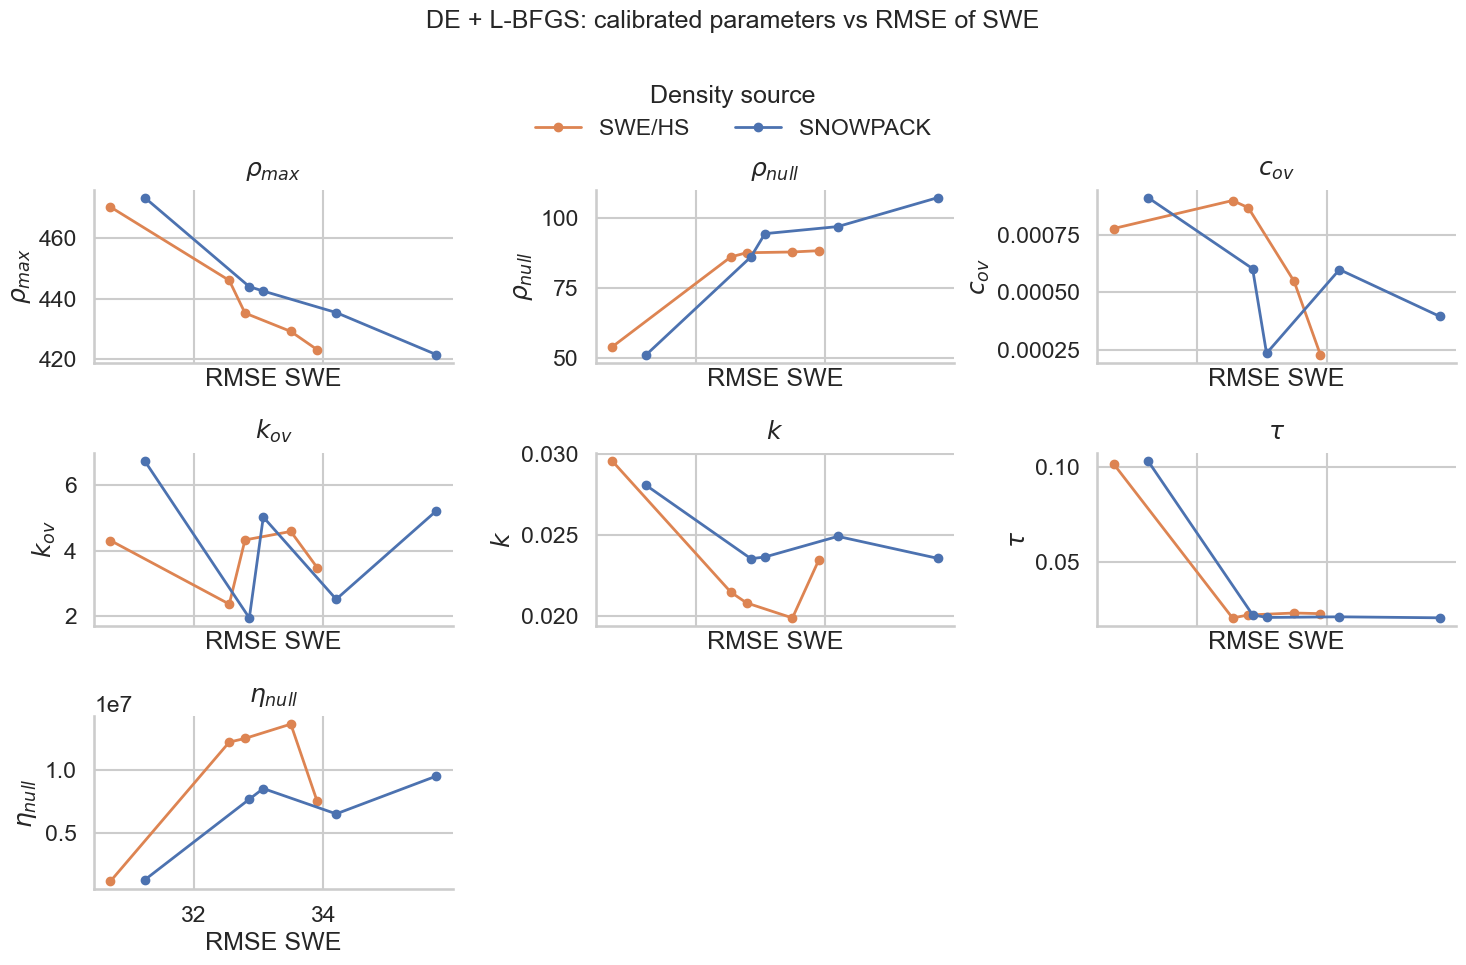

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

# Filter DE runs
de = dat[dat["algorithm"].str.contains("DE", na=False)].copy()

# Parameters to visualize
param_cols = ["rho_max", "rho_null", "c_ov", "k_ov", "k", "tau", "eta_null"]

# Nice axis labels
label_map = {
    "rho_max": r"$\rho_{max}$",
    "rho_null": r"$\rho_{null}$",
    "c_ov": r"$c_{ov}$",
    "k_ov": r"$k_{ov}$",
    "k": r"$k$",
    "tau": r"$\tau$",
    "eta_null": r"$\eta_{null}$"
}

n = len(param_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 9), sharex=True)
axes = axes.flatten()

rho_sources = list(de["rho_source"].dropna().unique())

for i, p in enumerate(param_cols):
    ax = axes[i]

    for rho in rho_sources:
        dd = de[de["rho_source"] == rho].sort_values("rmse_swe")

        ax.plot(
            dd["rmse_swe"],
            dd[p],
            marker="o",
            linewidth=2,
            markersize=6,
            color=color_map.get(rho, None),
            label=rho
        )

    ax.set_title(label_map.get(p, p), pad=10)
    ax.set_xlabel("RMSE SWE")
    ax.set_ylabel(label_map.get(p, p))

    # only keep left/bottom spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Hide unused panels
for j in range(len(param_cols), len(axes)):
    axes[j].set_visible(False)

# One shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title="Density source",
    loc="upper center",
    ncol=len(rho_sources),
    frameon=False,
    bbox_to_anchor=(0.5, 1.02)
)

fig.suptitle("DE + L-BFGS: calibrated parameters vs RMSE of SWE", fontsize=18, y=1.08)
plt.tight_layout()
plt.show()